In [1]:
import os
import sys
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import shap
import joblib

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.price_model.single_regressor.features import build_training_features, build_inference_features
from src.price_model.utils import dev_oot_split, prediction_bias
from src.price_model.tree_house import TreeHouse
from src.price_model.tree_house.features import build_training_features as build_th_features


DATA_DIR = os.environ.get("DATA_DIR", "../data")
MODELS_DIR = os.environ.get("MODELS_DIR", "../outputs/models")
conn = duckdb.connect(f"{DATA_DIR}/warehouse.duckdb", read_only=True)
os.makedirs(MODELS_DIR, exist_ok=True)

## Baseline check

In [ ]:
# Baseline pricing model peek

conn.sql(
"""
SELECT *
FROM gold.t1_baseline_pricing_model
WHERE item_id = 'ITM-0237'
AND customer_id = 'CUST-A'
AND vendor_id = 'VEND-02'
LIMIT 10
"""
)

┌─────────────┬──────────┬───────────┬────────────┬───────────────┬──────────────────────────┬─────────────────────────┐
│ customer_id │ item_id  │ vendor_id │ order_date │  daily_price  │ rolling_median_price_60d │ n_prior_days_with_price │
│   varchar   │ varchar  │  varchar  │    date    │ decimal(12,2) │      decimal(12,2)       │          int64          │
├─────────────┼──────────┼───────────┼────────────┼───────────────┼──────────────────────────┼─────────────────────────┤
│ CUST-A      │ ITM-0237 │ VEND-02   │ 2024-03-18 │          3.29 │                     NULL │                       0 │
│ CUST-A      │ ITM-0237 │ VEND-02   │ 2024-04-11 │          3.41 │                     3.29 │                       1 │
│ CUST-A      │ ITM-0237 │ VEND-02   │ 2024-04-12 │          3.07 │                     3.35 │                       2 │
│ CUST-A      │ ITM-0237 │ VEND-02   │ 2024-05-05 │          2.93 │                     3.29 │                       3 │
│ CUST-A      │ ITM-0237 │ VEND-

In [3]:
conn.sql("""
    SELECT
        POL.po_number,
        POL.item_id,
        POL.order_date,
        POL.unit_price_paid,
        PM.rolling_median_price_60d,
        POL.status
    FROM gold.fct_purchase_order_line POL
    LEFT JOIN gold.t1_baseline_pricing_model PM
        ON POL.item_id = PM.item_id
        AND POL.vendor_id = PM.vendor_id
        AND POL.customer_id = PM.customer_id
        AND POL.order_date = PM.order_date
    WHERE POL.customer_id = 'CUST-A'
    AND POL.vendor_id = 'VEND-02'
    AND POL.item_id = 'ITM-0237'
    ORDER BY order_date ASC
""")

┌───────────┬──────────┬────────────┬─────────────────┬──────────────────────────┬──────────┐
│ po_number │ item_id  │ order_date │ unit_price_paid │ rolling_median_price_60d │  status  │
│  varchar  │ varchar  │    date    │  decimal(12,2)  │      decimal(12,2)       │ varchar  │
├───────────┼──────────┼────────────┼─────────────────┼──────────────────────────┼──────────┤
│ PO-102065 │ ITM-0237 │ 2024-03-18 │            3.29 │                     NULL │ Received │
│ PO-102121 │ ITM-0237 │ 2024-04-11 │            3.41 │                     3.29 │ Received │
│ PO-100312 │ ITM-0237 │ 2024-04-12 │            3.07 │                     3.35 │ Received │
│ PO-102480 │ ITM-0237 │ 2024-05-05 │            2.93 │                     3.29 │ Received │
│ PO-102336 │ ITM-0237 │ 2024-05-09 │            3.19 │                     3.18 │ Received │
│ PO-100065 │ ITM-0237 │ 2024-05-17 │            2.88 │                     3.19 │ Closed   │
│ PO-102719 │ ITM-0237 │ 2024-06-07 │            2.98 │     

## Singular Regressor and TreeHouse training

In [2]:
df = conn.sql("""
    SELECT
        POL.po_number,
        POL.order_date,
        POL.customer_id,
        POL.vendor_id,
        POL.item_id,
        DI.description,
        DI.search_text,
        DI.category,
        DI.unit_of_measure,
        POL.unit_price_paid,
        POL.status
    FROM gold.fct_purchase_order_line POL
    INNER JOIN gold.dim_item DI
        ON POL.item_id = DI.item_id
    WHERE POL.status <> 'Cancelled'
""").df()

df["order_date"] = pd.to_datetime(df["order_date"])

n_orders = df["po_number"].nunique()
window = f"{df['order_date'].min():%b %Y} – {df['order_date'].max():%b %Y}"

print(f"{n_orders} orders, {df['item_id'].nunique()} items, {window}")


2809 orders, 120 items, Jan 2024 – Sep 2026


### Data fix: drop `ITM-0902` price-jump outliers

`ITM-0902` (cable staples, box of 100) has price lines from ~\$38 to ~\$48.50 against a typical paid price of ~\$4.44 -- a clean ~9-11x separation from every other price for the item (max non-jump price is \$5.06, min jump price is \$37.80). Treated as a decimal-placement error at the source, not a real price level. Simplest fix: drop these lines rather than impute a replacement value.

17 of the 19 known jump lines land in `df` (the other 2 sit on `Cancelled` orders already excluded by the query above).

In [3]:
# --- Data fix: drop ITM-0902 price-jump outliers -----------------------------
ITEM_ID = "ITM-0902"
JUMP_RATIO_THRESHOLD = 5.0  # jumps here run ~9-11x the item's typical price; nothing legitimate is close

item_median = df.loc[df["item_id"] == ITEM_ID, "unit_price_paid"].median()
is_jump = (df["item_id"] == ITEM_ID) & (df["unit_price_paid"] > JUMP_RATIO_THRESHOLD * item_median)

print(f"Dropping {is_jump.sum()} price-jump rows for {ITEM_ID}")
df = df[~is_jump].reset_index(drop=True)

Dropping 17 price-jump rows for ITM-0902


### Quick EDA

In [6]:
print(df["customer_id"].nunique())
df["customer_id"].value_counts(True)

8


customer_id
CUST-A    0.275809
CUST-B    0.185333
CUST-D    0.165614
CUST-F    0.096146
CUST-C    0.089831
CUST-H    0.081969
CUST-E    0.055935
CUST-G    0.049362
Name: proportion, dtype: float64

In [7]:
print(df["vendor_id"].nunique())
df["vendor_id"].value_counts(True)

12


vendor_id
VEND-12    0.093698
VEND-07    0.092795
VEND-10    0.090089
VEND-02    0.089187
VEND-01    0.087898
VEND-09    0.082485
VEND-08    0.081196
VEND-05    0.080294
VEND-06    0.080165
VEND-04    0.075654
VEND-03    0.073592
VEND-11    0.072948
Name: proportion, dtype: float64

In [8]:
print(df["category"].nunique())
df["category"].value_counts(True)

10


category
Wiring devices          0.198221
Connectors & lugs       0.182111
Conduit & fittings      0.180822
Fasteners & supports    0.133393
Tape & sealants         0.123856
Boxes & enclosures      0.082614
Grounding               0.034927
Circuit protection      0.030030
Lighting                0.026808
Wire & cable            0.007217
Name: proportion, dtype: float64

In [9]:
aux = df.drop_duplicates(subset=["vendor_id","category"])
pd.crosstab(aux["vendor_id"], aux["category"])

category,Boxes & enclosures,Circuit protection,Conduit & fittings,Connectors & lugs,Fasteners & supports,Grounding,Lighting,Tape & sealants,Wire & cable,Wiring devices
vendor_id,,,,,,,,,,
VEND-01,1,1,1,1,1,0,0,1,0,1
VEND-02,1,0,1,1,1,1,0,1,0,1
VEND-03,1,0,1,1,1,1,1,1,1,1
VEND-04,1,1,1,1,1,0,1,1,0,1
VEND-05,1,1,1,1,1,1,1,1,0,1
VEND-06,1,0,1,1,1,1,1,1,1,1
VEND-07,1,1,1,1,1,0,1,1,1,1
VEND-08,1,1,1,1,1,0,1,1,0,1
VEND-09,1,1,1,1,1,1,1,1,0,1


In [10]:
aux = df.drop_duplicates(subset=["po_number","category", "unit_of_measure"])

display(aux["unit_of_measure"].value_counts(True))
display(aux["category"].value_counts(True))
pd.crosstab(aux["unit_of_measure"], aux["category"])

unit_of_measure
EA    0.862515
BG    0.062128
BX    0.059602
RL    0.008323
PK    0.007432
Name: proportion, dtype: float64

category
Connectors & lugs       0.190547
Wiring devices          0.175832
Conduit & fittings      0.163496
Fasteners & supports    0.141498
Tape & sealants         0.132729
Boxes & enclosures      0.087099
Grounding               0.038942
Circuit protection      0.031510
Lighting                0.030024
Wire & cable            0.008323
Name: proportion, dtype: float64

category,Boxes & enclosures,Circuit protection,Conduit & fittings,Connectors & lugs,Fasteners & supports,Grounding,Lighting,Tape & sealants,Wire & cable,Wiring devices
unit_of_measure,,,,,,,,,,
BG,0,0,0,274,0,0,0,144,0,0
BX,0,0,0,130,271,0,0,0,0,0
EA,586,212,1100,878,681,262,202,699,0,1183
PK,0,0,0,0,0,0,0,50,0,0
RL,0,0,0,0,0,0,0,0,56,0


### Singular Regressor

Features: `item_id`, `customer_id`, `vendor_id`, `category`, `unit_of_measure` all leakage-safe expanding target-encoded (see `src/price_model/single_regressor`), plus `days_since_start` for the secular price trend. Target is `log1p(unit_price_paid)` to stabilize variance across the item price range.

Split: dev pool (everything before 2026-07-01) used for `TimeSeriesSplit` tuning and the final training fit; OOT (2026 Q3) touched once at the end.

In [4]:
GROUP_COLS = ("item_id", "customer_id", "vendor_id", "category", "unit_of_measure")
TARGET_COL = "unit_price_paid"
DATE_COL = "order_date"
OOT_START = "2026-07-01"

origin = df[DATE_COL].min()
feat_df, encoders = build_training_features(
    df,
    target_col=TARGET_COL,
    date_col=DATE_COL,
    origin=origin,
    smoothing=10.0,
    group_cols=GROUP_COLS,
)
feat_df["log_price"] = np.log1p(feat_df[TARGET_COL])

FEATURE_COLS = [f"{c}_te" for c in GROUP_COLS] + ["days_since_start"]

# The very first historical row overall has no prior data at all (genuinely
# unknowable, by design -- see ExpandingTargetEncoder), drop it from training.
feat_df = feat_df.dropna(subset=FEATURE_COLS + ["log_price"]).reset_index(drop=True)

dev, oot = dev_oot_split(feat_df, date_col=DATE_COL, oot_start=OOT_START)
dev = dev.sort_values(DATE_COL).reset_index(drop=True)
oot = oot.sort_values(DATE_COL).reset_index(drop=True)

print(f"dev: {len(dev)} rows ({dev[DATE_COL].min():%Y-%m-%d} -> {dev[DATE_COL].max():%Y-%m-%d})")
print(f"oot: {len(oot)} rows ({oot[DATE_COL].min():%Y-%m-%d} -> {oot[DATE_COL].max():%Y-%m-%d})")

dev: 7189 rows (2024-01-02 -> 2026-06-30)
oot: 547 rows (2026-07-01 -> 2026-09-01)


#### Hyperparameter tuning: walk-forward `TimeSeriesSplit` over the dev pool

Small grid, scored by mean MAE in dollars (log predictions are converted back with `expm1` before scoring, since that's the unit that matters for the business question).

In [5]:
PARAM_GRID = [
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.10},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.03},
]

tscv = TimeSeriesSplit(n_splits=5)
X_dev, y_dev = dev[FEATURE_COLS], dev["log_price"]

cv_results = []
for params in PARAM_GRID:
    fold_maes = []
    for train_idx, val_idx in tscv.split(X_dev):
        model = XGBRegressor(
            **params,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
        pred = np.expm1(model.predict(X_dev.iloc[val_idx]))
        actual = np.expm1(y_dev.iloc[val_idx])
        fold_maes.append(mean_absolute_error(actual, pred))
    cv_results.append({**params, "cv_mae": np.mean(fold_maes)})

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_mae")
cv_results_df

,n_estimators,max_depth,learning_rate,cv_mae
3,500,6,0.03,1.461106
2,400,5,0.05,1.519389
1,300,4,0.05,1.572816
0,200,3,0.10,1.711303


#### Final fit on the full dev pool, scored once on OOT

In [6]:
best_params = cv_results_df.iloc[0][["n_estimators", "max_depth", "learning_rate"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
print("best params:", best_params)

single_regressor = XGBRegressor(
    **best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
single_regressor.fit(X_dev, y_dev)

X_oot, y_oot_log = oot[FEATURE_COLS], oot["log_price"]
y_oot = oot[TARGET_COL].to_numpy()
pred_oot = np.expm1(single_regressor.predict(X_oot))

metrics = {
    "MAE": mean_absolute_error(y_oot, pred_oot),
    "RMSE": mean_squared_error(y_oot, pred_oot) ** 0.5,
    "MAPE": mean_absolute_percentage_error(y_oot, pred_oot),
    "R2": r2_score(y_oot, pred_oot),
}
print(metrics)
print(prediction_bias(y_oot, pred_oot))

best params: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03}
{'MAE': 0.7585783670131641, 'RMSE': 1.4500913854133346, 'MAPE': 0.18832811380491377, 'R2': 0.9904610229307672}
{'mean_ratio': 1.0337514043300655, 'median_ratio': 0.972024883542742, 'pct_underpredicted': 59.597806215722116}


Bias check: the tree-extrapolation risk we flagged earlier — if `mean_ratio`/`median_ratio` are meaningfully below 1.0, the model is systematically underpredicting on OOT because it never saw prices this high during training. Decide from this evidence whether a ratio/residual reframing of the target is worth doing, rather than pre-building it.

#### SHAP: what is the model actually using?

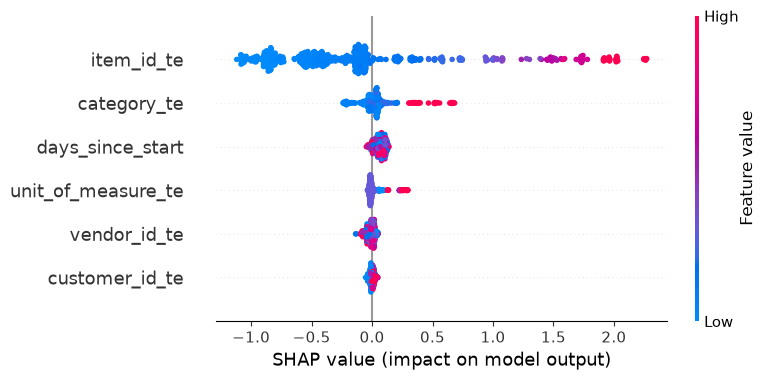

In [14]:
explainer = shap.TreeExplainer(single_regressor)
shap_values = explainer(X_oot)
shap.summary_plot(shap_values, X_oot, show=False)
plt.tight_layout()

#### Beyond feature importance: a human-readable "why this price" breakdown

The summary plot ranks target-encoded *columns*, which isn't label-level attribution (`item_id_te` doesn't say *which* item, or what that item's own history looks like). Since the target is `log1p(price)` and SHAP is additive, each feature's SHAP value converts *exactly* into a multiplicative % price effect via `exp(shap) - 1` -- no approximation. Combined with a raw-label lookup (item description, vendor name, ...) and the number of prior observations backing each encoding (flagged only when it's below the encoder's `smoothing` constant, i.e. the encoding is leaning more on the global prior than on that entity's own history), this turns one row's SHAP values into a ranked, readable explanation of one predicted price.

In [15]:
# --- Human-readable per-prediction price breakdown ---------------------------
item_desc = df.drop_duplicates("item_id").set_index("item_id")["description"].to_dict()
vendor_name = (
    conn.sql("SELECT vendor_id, vendor_name FROM gold.dim_vendor")
    .df()
    .set_index("vendor_id")["vendor_name"]
    .to_dict()
)

FEATURE_LABELS = {
    "item_id_te": "item",
    "customer_id_te": "customer",
    "vendor_id_te": "vendor",
    "category_te": "category",
    "unit_of_measure_te": "unit of measure",
}


def _raw_label(group_col: str, value: str) -> str:
    if group_col == "item_id":
        return f"{value} -- {item_desc.get(value, 'unknown item')}"
    if group_col == "vendor_id":
        return f"{value} -- {vendor_name.get(value, 'unknown vendor')}"
    return str(value)


def _n_prior_observations(group_col: str, value: str, asof_date: pd.Timestamp) -> int:
    """Count of this group value's own strictly-prior, non-null observations
    in the full historical frame -- the same population the encoder's
    `prior_group_count` is built from, recomputed directly rather than pulled
    out of the encoder (which only keeps final grand totals, not per-row
    history)."""
    mask = (
        (feat_df[group_col] == value)
        & (feat_df[DATE_COL] < asof_date)
        & feat_df[TARGET_COL].notna()
    )
    return int(mask.sum())


def explain_prediction(row_pos: int, smoothing: float = 10.0) -> pd.DataFrame:
    """Ranked, human-readable price breakdown for one OOT row.

    Converts each feature's SHAP value (additive on log1p(price)) into an
    exact multiplicative % price effect, relabels target-encoded columns back
    to their raw values (item description, vendor name, ...), and flags any
    driver whose encoding rests on fewer prior observations than the
    encoder's smoothing constant -- i.e. it is leaning mostly on the global
    prior rather than that entity's own history.
    """
    row = oot.iloc[row_pos]
    sv = shap_values[row_pos]
    base_value = float(sv.base_values)
    pred_log = base_value + sv.values.sum()

    entries = []
    for col in GROUP_COLS:
        te_col = f"{col}_te"
        shap_val = float(sv.values[FEATURE_COLS.index(te_col)])
        n_prior = _n_prior_observations(col, row[col], row[DATE_COL])
        entries.append(
            {
                "driver": FEATURE_LABELS[te_col],
                "label": _raw_label(col, row[col]),
                "pct_effect": (np.exp(shap_val) - 1) * 100,
                "n_prior": n_prior,
                "thin_history": n_prior < smoothing,
                "abs_shap": abs(shap_val),
            }
        )

    shap_val = float(sv.values[FEATURE_COLS.index("days_since_start")])
    entries.append(
        {
            "driver": "time trend",
            "label": f"{row[DATE_COL]:%Y-%m-%d}",
            "pct_effect": (np.exp(shap_val) - 1) * 100,
            "n_prior": None,
            "thin_history": False,
            "abs_shap": abs(shap_val),
        }
    )

    entries.sort(key=lambda e: -e["abs_shap"])

    print(f"PO {row['po_number']} -- item {row['item_id']} on {row[DATE_COL]:%Y-%m-%d}")
    print(
        f"Predicted: ${np.expm1(pred_log):,.2f}   "
        f"(population baseline: ${np.expm1(base_value):,.2f})   "
        f"Actual paid: ${row[TARGET_COL]:,.2f}"
    )
    for e in entries:
        sign = "+" if e["pct_effect"] >= 0 else "-"
        note = f"  [only {e['n_prior']} prior obs]" if e["thin_history"] else ""
        print(f"  {e['driver']:<15} {e['label']:<45} {sign}{abs(e['pct_effect']):5.1f}%{note}")

    return pd.DataFrame(entries)


explain_prediction(0)

PO PO-102919 -- item ITM-1015 on 2026-07-01
Predicted: $4.56   (population baseline: $4.07)   Actual paid: $4.75
  time trend      2026-07-01                                    + 10.6%
  item            ITM-1015 -- Heat Shrink Tubing 1/2in Black 4ft -  5.7%
  category        Tape & sealants                               +  3.7%
  vendor          VEND-12 -- Voltec Supply Group                +  1.2%
  customer        CUST-D                                        +  0.5%
  unit of measure EA                                            -  0.5%


,driver,label,pct_effect,n_prior,thin_history,abs_shap
0,time trend,2026-07-01,10.610193,NaN,False,0.100842
1,item,ITM-1015 -- Heat Shrink Tubing 1/2in Black 4ft,-5.671064,300.0,False,0.058382
2,category,Tape & sealants,3.653952,881.0,False,0.035888
3,vendor,VEND-12 -- Voltec Supply Group,1.228604,676.0,False,0.012211
4,customer,CUST-D,0.526932,1173.0,False,0.005255
5,unit of measure,EA,-0.452783,6318.0,False,0.004538


In [ ]:
joblib.dump(single_regressor, f"{MODELS_DIR}/t1_single_regressor.joblib")

['t1_single_regressor.joblib']

### TreeHouse

`item_id` is not a feature. The description stands in for it: MiniLM (`all-MiniLM-L6-v2`, the encoder item search already uses) reduced with PCA, plus the numeric specs in the description (AWG, trade size, amps, watts, length, gang, pack size, poles, switch ways, panel spaces, enclosure and fixture dimensions). A missing spec stays missing. A pretrained NER model has nothing to find in this catalog — these strings are part attributes, not entities — so the specs are patterns, not spaCy.

The router is two binary classifiers, `P(bucket >= mid)` and `P(bucket == high)`, not a 3-class softmax. Softmax treats low-vs-high as the same kind of mistake as low-vs-mid. Customer, vendor, category, and unit of measure go in as expanding WOE, one encoding per cut. The experts are `XGBRegressor`s on `log1p(unit_price_paid)`, one per true tertile; at prediction time the router picks the expert. Category is already known, so nothing tries to predict it.

Buckets are tertiles of `unit_price_paid` fit on the dev pool only, then frozen and applied to the holdout. Same split as the single regressor (`OOT_START = 2026-07-01`). Order quantity is left out, so both models see the same kind of inputs and a quote does not depend on a quantity that may not be known yet. The bar from the single regressor, after the `ITM-0902` drop, is MAE $0.76 on this same holdout.


In [7]:
TARGET_COL = "unit_price_paid"
DATE_COL = "order_date"
OOT_START = "2026-07-01"

th_frame, th_artifacts = build_th_features(
    df,
    target_col=TARGET_COL,
    date_col=DATE_COL,
    origin=df[DATE_COL].min(),
    oot_start=OOT_START,
)

# Target encoding is undefined on the first calendar day (no prior price).
# Do not dropna the spec columns: a wire has no amperage, a breaker has no AWG,
# and that missingness is a real feature.
te_cols = [c for c in th_artifacts["expert_cols"] if c.endswith("_te")]
th_frame = th_frame.dropna(subset=te_cols + [TARGET_COL, "price_bucket"]).reset_index(drop=True)

th_dev, th_oot = dev_oot_split(th_frame, date_col=DATE_COL, oot_start=OOT_START)
th_dev = th_dev.sort_values(DATE_COL).reset_index(drop=True)
th_oot = th_oot.sort_values(DATE_COL).reset_index(drop=True)

q33, q66 = th_artifacts["cuts"]
var_kept = th_artifacts["embedder"].pca_.explained_variance_ratio_.sum()
n_comp = th_artifacts["embedder"].pca_.n_components_
print(f"tertile cuts (dev pool): low < ${q33:.2f} <= mid < ${q66:.2f} <= high")
print(f"PCA variance kept: {var_kept:.1%} in {n_comp} components")
print(f"dev: {len(th_dev)} rows ({th_dev[DATE_COL].min():%Y-%m-%d} -> {th_dev[DATE_COL].max():%Y-%m-%d})")
print(f"oot: {len(th_oot)} rows ({th_oot[DATE_COL].min():%Y-%m-%d} -> {th_oot[DATE_COL].max():%Y-%m-%d})")
print("dev bucket mix:")
print(th_dev["price_bucket"].value_counts(normalize=True).sort_index().round(3))
print("oot bucket mix:")
print(th_oot["price_bucket"].value_counts(normalize=True).sort_index().round(3))


tertile cuts (dev pool): low < $2.22 <= mid < $4.35 <= high
PCA variance kept: 70.3% in 16 components
dev: 7189 rows (2024-01-02 -> 2026-06-30)
oot: 547 rows (2026-07-01 -> 2026-09-01)
dev bucket mix:
price_bucket
0    0.333
1    0.332
2    0.335
Name: proportion, dtype: Float64
oot bucket mix:
price_bucket
0    0.311
1    0.302
2    0.388
Name: proportion, dtype: Float64


#### Hyperparameter tuning

The router stays fixed (`n_estimators=300`, `max_depth=4`, `learning_rate=0.05`). The grid is only the expert, and it is the same four configs as the single regressor, scored by walk-forward MAE in dollars. If the router accuracy below is the weak spot, this grid will not show it — that is a separate knob.


In [8]:
CLASSIFIER_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
}

PARAM_GRID = [
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.10},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.03},
]

tscv = TimeSeriesSplit(n_splits=5)
cv_results = []
for params in PARAM_GRID:
    fold_maes = []
    for train_idx, val_idx in tscv.split(th_dev):
        model = TreeHouse(classifier_params=CLASSIFIER_PARAMS, regressor_params=params)
        train = th_dev.iloc[train_idx]
        val = th_dev.iloc[val_idx]
        model.fit(
            train,
            train[TARGET_COL],
            router_cols=th_artifacts["router_cols"],
            expert_cols=th_artifacts["expert_cols"],
            cuts=th_artifacts["cuts"],
        )
        pred = model.predict(val)
        fold_maes.append(mean_absolute_error(val[TARGET_COL], pred))
    cv_results.append({**params, "cv_mae": float(np.mean(fold_maes))})

th_cv_results_df = pd.DataFrame(cv_results).sort_values("cv_mae")
th_cv_results_df


,n_estimators,max_depth,learning_rate,cv_mae
1,300,4,0.05,0.358081
0,200,3,0.10,0.362422
2,400,5,0.05,0.362862
3,500,6,0.03,0.373325


#### Final fit on the full dev pool, scored once on OOT

`oracle-route MAE` sends each holdout row to the expert for its true bucket. The gap between that and the routed MAE is what the router costs. Router accuracy is exact-bucket; the mean absolute bucket error treats low-vs-high (2) as worse than low-vs-mid (1).


In [9]:
best_params = th_cv_results_df.iloc[0][["n_estimators", "max_depth", "learning_rate"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
print("best expert params:", best_params)

tree_house = TreeHouse(classifier_params=CLASSIFIER_PARAMS, regressor_params=best_params)
tree_house.fit(
    th_dev,
    th_dev[TARGET_COL],
    router_cols=th_artifacts["router_cols"],
    expert_cols=th_artifacts["expert_cols"],
    cuts=th_artifacts["cuts"],
)

detail = tree_house.predict_detail(th_oot)
th_pred_oot = detail["predicted_price"].to_numpy()
th_y_oot = th_oot[TARGET_COL].to_numpy()
oracle = tree_house.predict_given_bucket(th_oot, th_oot["price_bucket"])

metrics = {
    "MAE": mean_absolute_error(th_y_oot, th_pred_oot),
    "RMSE": mean_squared_error(th_y_oot, th_pred_oot) ** 0.5,
    "MAPE": mean_absolute_percentage_error(th_y_oot, th_pred_oot),
    "R2": r2_score(th_y_oot, th_pred_oot),
}
print(metrics)
print(prediction_bias(th_y_oot, th_pred_oot))

true_bucket = th_oot["price_bucket"].astype(int).to_numpy()
routed = detail["predicted_bucket"].to_numpy()
print(f"router accuracy: {(routed == true_bucket).mean():.1%}")
print(f"router mean |bucket error|: {np.abs(routed - true_bucket).mean():.3f}")
print(f"oracle-route MAE: ${mean_absolute_error(th_y_oot, oracle):.3f}")
print(f"routed MAE:       ${mean_absolute_error(th_y_oot, th_pred_oot):.3f}")


best expert params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
{'MAE': 0.36187561466429813, 'RMSE': 0.8847503283582827, 'MAPE': 0.04152523355125456, 'R2': 0.9964489848538417}
{'mean_ratio': 0.9967019190786922, 'median_ratio': 0.9898308636586631, 'pct_underpredicted': 55.94149908592322}
router accuracy: 94.3%
router mean |bucket error|: 0.057
oracle-route MAE: $0.355
routed MAE:       $0.362


In [21]:
BUCKET_LABELS = {0: "low", 1: "mid", 2: "high"}

# Build once and reuse. There are at most three specialists.
expert_explainers = {
    level: shap.TreeExplainer(model)
    for level, model in tree_house.experts_.items()
}
fallback_explainer = shap.TreeExplainer(tree_house.fallback_)


def explain_treehouse_row(row_pos: int) -> pd.DataFrame:
    """SHAP for the expert that priced this out-of-time row."""
    row = th_oot.iloc[[row_pos]]
    bucket = int(detail["predicted_bucket"].iloc[row_pos])
    if bucket in expert_explainers:
        explainer = expert_explainers[bucket]
        model_name = f"{BUCKET_LABELS[bucket]} expert"
    else:
        explainer = fallback_explainer
        model_name = "fallback (all rows)"

    X = row[tree_house.expert_cols_]
    sv = explainer(X)[0]

    pred_log = float(sv.base_values) + float(sv.values.sum())
    pred_price = float(np.expm1(pred_log))

    table = pd.DataFrame({
        "feature": list(tree_house.expert_cols_),
        "value": X.iloc[0].to_numpy(),
        "shap_log1p": sv.values,
    })
    table["pct_effect"] = (np.exp(table["shap_log1p"]) - 1) * 100
    table["abs_shap"] = table["shap_log1p"].abs()
    table = table.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    actual = th_oot.iloc[row_pos][TARGET_COL]
    print(
        f"row {row_pos} routed to {model_name}\n"
        f"baseline (1+price): ${np.expm1(float(sv.base_values)):,.2f}   "
        f"SHAP price: ${pred_price:,.2f}   "
        f"routed price: ${detail['predicted_price'].iloc[row_pos]:,.2f}   "
        f"actual: ${actual:,.2f}"
    )
    return table


explain_treehouse_row(0)

row 0 routed to high expert
baseline (1+price): $12.95   SHAP price: $4.65   routed price: $4.65   actual: $4.75


,feature,value,shap_log1p,pct_effect,abs_shap
0,emb_06,-0.273950,-0.327551,-27.931326,0.327551
1,category_te,3.945444,-0.302809,-26.126003,0.302809
2,emb_12,-0.104835,-0.100944,-9.601652,0.100944
3,emb_07,0.083085,-0.093379,-8.915215,0.093379
4,emb_11,-0.155244,-0.078925,-7.589072,0.078925
5,emb_00,-0.060716,-0.062017,-6.013268,0.062017
6,emb_13,0.334480,0.050388,5.167949,0.050388
7,emb_09,0.193320,0.032614,3.315115,0.032614
8,size_in,0.500000,-0.032420,-3.190035,0.032420
9,emb_02,-0.103664,0.030737,3.121412,0.030737


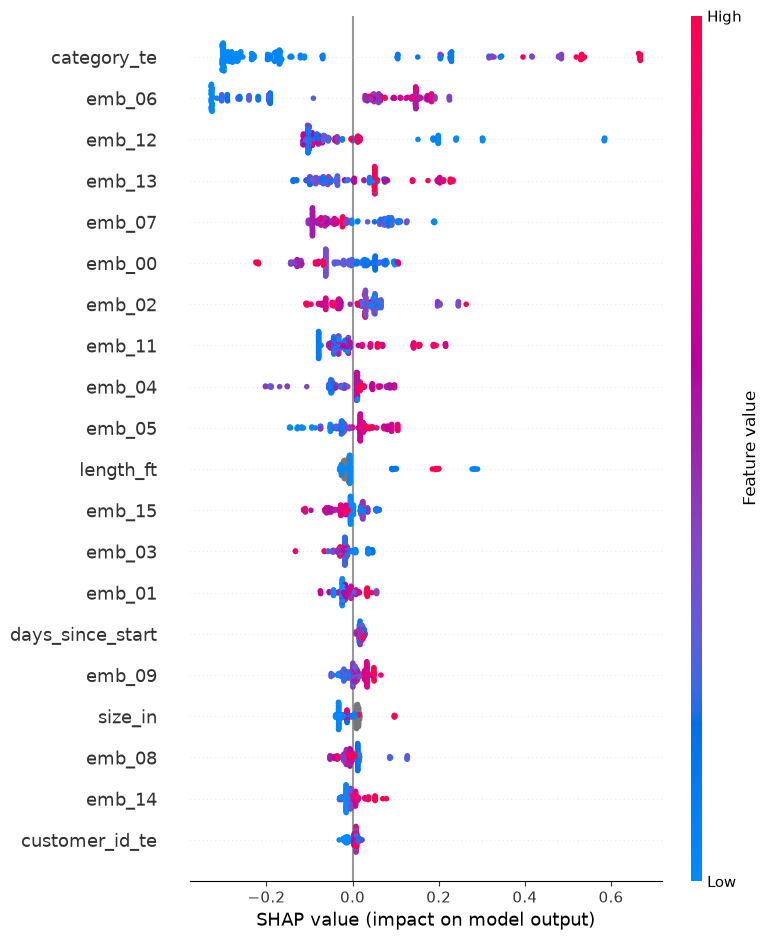

In [22]:
def shap_for_routed_bucket(level: int):
    mask = detail["predicted_bucket"].to_numpy() == level
    X = th_oot.loc[mask, tree_house.expert_cols_]
    explainer = expert_explainers.get(level, fallback_explainer)
    return explainer(X), X


sv_high, X_high = shap_for_routed_bucket(2)  # rows the router sent to high
shap.summary_plot(sv_high, X_high, max_display=20, show=False)
plt.tight_layout()

In [23]:
from src.price_model.tree_house.attributes import SPEC_COLUMNS

BUCKET_LABELS = {0: "low", 1: "mid", 2: "high"}
TE_DRIVERS = {
    "customer_id_te": ("customer", "customer_id"),
    "vendor_id_te": ("vendor", "vendor_id"),
    "category_te": ("category", "category"),
    "unit_of_measure_te": ("unit of measure", "unit_of_measure"),
}
SPEC_PRETTY = {
    "awg": ("wire gauge", "AWG"),
    "n_conductors": ("conductors", ""),
    "size_in": ("trade size", "in"),
    "amps": ("amperage", "A"),
    "watts": ("wattage", "W"),
    "length_ft": ("length", "ft"),
    "gang": ("gang", ""),
    "pack_qty": ("pack size", ""),
    "n_poles": ("poles", ""),
    "n_ways": ("ways", ""),
    "n_spaces": ("spaces", ""),
    "box_l": ("box length", "in"),
    "box_w": ("box width", "in"),
    "box_h": ("box height", "in"),
    "nominal_w": ("nominal width", "in"),
    "nominal_h": ("nominal height", "in"),
}

item_desc = df.drop_duplicates("item_id").set_index("item_id")["description"].to_dict()
vendor_name = (
    conn.sql("SELECT vendor_id, vendor_name FROM gold.dim_vendor")
    .df()
    .set_index("vendor_id")["vendor_name"]
    .to_dict()
)
history = pd.concat([th_dev, th_oot], ignore_index=True)
expert_explainers = {
    level: shap.TreeExplainer(model) for level, model in tree_house.experts_.items()
}
fallback_explainer = shap.TreeExplainer(tree_house.fallback_)


def _raw_label(group_col: str, value: str) -> str:
    if group_col == "vendor_id":
        return f"{value} -- {vendor_name.get(value, 'unknown vendor')}"
    return str(value)


def _n_prior(group_col: str, value: str, asof: pd.Timestamp) -> int:
    mask = (
        (history[group_col].astype(str) == str(value))
        & (history[DATE_COL] < asof)
        & history[TARGET_COL].notna()
    )
    return int(mask.sum())


def _spec_label(col: str, value) -> str:
    name, unit = SPEC_PRETTY[col]
    if pd.isna(value):
        return f"{name}: not in the description"
    number = f"{value:g}"
    return f"{name}: {number} {unit}".rstrip()


def explain_treehouse_prediction(row_pos: int, min_spec_pct: float = 0.5) -> pd.DataFrame:
    """Same printout as the single regressor, for the expert that priced this row.

    Target encodings are labeled with the raw category. The 16 embedding
    components are one description vector, so their SHAP values are summed
    in log space and labeled with that description. A parsed spec is listed
    on its own when it moves the price by at least `min_spec_pct`.
    """
    row = th_oot.iloc[row_pos]
    bucket = int(detail["predicted_bucket"].iloc[row_pos])
    if bucket in expert_explainers:
        explainer = expert_explainers[bucket]
        model_name = f"{BUCKET_LABELS[bucket]} expert"
    else:
        explainer = fallback_explainer
        model_name = "fallback"

    X = th_oot.iloc[[row_pos]][tree_house.expert_cols_]
    sv = explainer(X)[0]
    shap_by_name = dict(zip(tree_house.expert_cols_, sv.values))
    base_value = float(sv.base_values)
    pred_log = base_value + float(sv.values.sum())
    smoothing = next(iter(th_artifacts["target_encoders"].values())).smoothing

    entries = []
    for te_col, (driver, group_col) in TE_DRIVERS.items():
        shap_val = float(shap_by_name[te_col])
        n_prior = _n_prior(group_col, row[group_col], row[DATE_COL])
        entries.append({
            "driver": driver,
            "label": _raw_label(group_col, row[group_col]),
            "pct_effect": (np.exp(shap_val) - 1) * 100,
            "n_prior": n_prior,
            "thin_history": n_prior < smoothing,
            "abs_shap": abs(shap_val),
        })

    emb_cols = [c for c in tree_house.expert_cols_ if c.startswith("emb_")]
    emb_shap = float(sum(shap_by_name[c] for c in emb_cols))
    description = item_desc.get(row["item_id"], row.get("description", ""))
    n_prior_desc = _n_prior("item_id", row["item_id"], row[DATE_COL])
    entries.append({
        "driver": "description",
        "label": str(description),
        "pct_effect": (np.exp(emb_shap) - 1) * 100,
        "n_prior": n_prior_desc,
        "thin_history": n_prior_desc < smoothing,
        "abs_shap": abs(emb_shap),
    })

    for col in SPEC_COLUMNS:
        if col not in shap_by_name:
            continue
        shap_val = float(shap_by_name[col])
        pct = (np.exp(shap_val) - 1) * 100
        if abs(pct) < min_spec_pct:
            continue
        entries.append({
            "driver": SPEC_PRETTY[col][0],
            "label": _spec_label(col, row[col]),
            "pct_effect": pct,
            "n_prior": None,
            "thin_history": False,
            "abs_shap": abs(shap_val),
        })

    shap_val = float(shap_by_name["days_since_start"])
    entries.append({
        "driver": "time trend",
        "label": f"{row[DATE_COL]:%Y-%m-%d}",
        "pct_effect": (np.exp(shap_val) - 1) * 100,
        "n_prior": None,
        "thin_history": False,
        "abs_shap": abs(shap_val),
    })

    entries.sort(key=lambda e: -e["abs_shap"])
    print(
        f"PO {row['po_number']} -- item {row['item_id']} on {row[DATE_COL]:%Y-%m-%d}  "
        f"[{model_name}]"
    )
    print(
        f"Predicted: ${np.expm1(pred_log):,.2f}   "
        f"(expert baseline: ${np.expm1(base_value):,.2f})   "
        f"Actual paid: ${row[TARGET_COL]:,.2f}"
    )
    for e in entries:
        sign = "+" if e["pct_effect"] >= 0 else "-"
        note = f"  [only {e['n_prior']} prior obs]" if e["thin_history"] else ""
        print(f"  {e['driver']:<15} {e['label']:<45} {sign}{abs(e['pct_effect']):5.1f}%{note}")
    return pd.DataFrame(entries)


explain_treehouse_prediction(0)

PO PO-102919 -- item ITM-1015 on 2026-07-01  [high expert]
Predicted: $4.65   (expert baseline: $12.95)   Actual paid: $4.75
  description     Heat Shrink Tubing 1/2in Black 4ft            - 44.0%
  category        Tape & sealants                               - 26.1%
  trade size      trade size: 0.5 in                            -  3.2%
  time trend      2026-07-01                                    +  1.6%
  wattage         wattage: not in the description               -  0.6%
  length          length: 4 ft                                  -  0.6%
  vendor          VEND-12 -- Voltec Supply Group                +  0.4%
  customer        CUST-D                                        +  0.3%
  unit of measure EA                                            -  0.1%


,driver,label,pct_effect,n_prior,thin_history,abs_shap
0,description,Heat Shrink Tubing 1/2in Black 4ft,-43.980511,300.0,False,0.579471
1,category,Tape & sealants,-26.125999,881.0,False,0.302809
2,trade size,trade size: 0.5 in,-3.190033,NaN,False,0.032420
3,time trend,2026-07-01,1.557102,NaN,False,0.015451
4,wattage,wattage: not in the description,-0.644217,NaN,False,0.006463
5,length,length: 4 ft,-0.629646,NaN,False,0.006316
6,vendor,VEND-12 -- Voltec Supply Group,0.435524,676.0,False,0.004346
7,customer,CUST-D,0.315065,1173.0,False,0.003146
8,unit of measure,EA,-0.132000,6318.0,False,0.001321


In [ ]:
# The booster only. Scoring a new PO also needs `th_artifacts`
# (PCA, WOE, target encoders). That object holds MiniLM, so it is a much larger file.
joblib.dump(tree_house, f"{MODELS_DIR}/t1_tree_house.joblib")


## Comparison

All three are scored on the out-of-time window, 2026-07-01 onward. The baseline prediction is `rolling_median_price_60d` from `gold.t1_baseline_pricing_model`. That median is null when the customer, item, and vendor have no purchase in the prior 60 days, so the baseline row uses only the lines it can price. The model rows directly under it are the full holdout. When the baseline skips lines, the last two rows rescore both models on the lines it does answer, so the comparison is the same set of purchases.


In [14]:
LINE_KEYS = ["po_number", "customer_id", "item_id", "vendor_id", "order_date", "unit_price_paid"]
PRICE_KEYS = ["customer_id", "item_id", "vendor_id", "order_date"]

baseline = conn.sql("""
    SELECT
        customer_id,
        item_id,
        vendor_id,
        order_date,
        rolling_median_price_60d
    FROM gold.t1_baseline_pricing_model
""").df()
baseline["order_date"] = pd.to_datetime(baseline["order_date"])

eval_df = oot[LINE_KEYS].copy()
# Predict again from the fitted single regressor. `pred_oot` is not safe:
# the TreeHouse cell used to write its own predictions into that name.
sr_pred_oot = np.expm1(single_regressor.predict(oot[FEATURE_COLS]))
eval_df["sr_pred"] = sr_pred_oot
eval_df = eval_df.merge(baseline, on=PRICE_KEYS, how="left", validate="many_to_one")

th_attach = th_oot[LINE_KEYS].copy()
th_attach["th_pred"] = detail["predicted_price"].to_numpy()
eval_df = eval_df.sort_values(LINE_KEYS, kind="mergesort")
th_attach = th_attach.sort_values(LINE_KEYS, kind="mergesort")
eval_df["_occ"] = eval_df.groupby(LINE_KEYS, sort=False).cumcount()
th_attach["_occ"] = th_attach.groupby(LINE_KEYS, sort=False).cumcount()
eval_df = eval_df.merge(
    th_attach[LINE_KEYS + ["_occ", "th_pred"]],
    on=LINE_KEYS + ["_occ"],
    how="left",
    validate="one_to_one",
)

covered = eval_df["rolling_median_price_60d"].notna()
y_base = eval_df.loc[covered, "unit_price_paid"].to_numpy(dtype=float)
p_base = eval_df.loc[covered, "rolling_median_price_60d"].to_numpy(dtype=float)

baseline_metrics = {
    "n": int(covered.sum()),
    "MAE": mean_absolute_error(y_base, p_base),
    "RMSE": mean_squared_error(y_base, p_base) ** 0.5,
    "MAPE": mean_absolute_percentage_error(y_base, p_base),
    "R2": r2_score(y_base, p_base),
}
baseline_bias = prediction_bias(y_base, p_base)
print(f"baseline covers {covered.sum()} of {len(eval_df)} OOT lines")
print(baseline_metrics)
print(baseline_bias)


baseline covers 190 of 547 OOT lines
{'n': 190, 'MAE': 0.48678947368421044, 'RMSE': 3.2104379927454074, 'MAPE': 0.08610866491049923, 'R2': 0.9310256391861474}
{'mean_ratio': 1.042997982953163, 'median_ratio': 0.9934559831011647, 'pct_underpredicted': 52.10526315789473}


In [20]:
def price_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    row = {
        "n": int(len(y_true)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    row.update(prediction_bias(y_true, y_pred))
    return row

rows = {
    "Baseline": {**baseline_metrics, **baseline_bias},
    "Single regressor": price_metrics(oot["unit_price_paid"], sr_pred_oot),
    "TreeHouse": price_metrics(th_oot["unit_price_paid"], detail["predicted_price"]),
}
if covered.sum() < len(eval_df):
    part = eval_df.loc[covered]
    rows["Single regressor, baseline rows"] = price_metrics(part["unit_price_paid"], part["sr_pred"])
    rows["TreeHouse, baseline rows"] = price_metrics(part["unit_price_paid"], part["th_pred"])

comparison = pd.DataFrame(rows).T
comparison["MAPE"] = comparison["MAPE"] * 100
comparison = comparison.rename(columns={"MAPE": "MAPE %"})
comparison = comparison.round({
    "MAE": 3,
    "RMSE": 3,
    "MAPE %": 1,
    "R2": 3,
    "mean_ratio": 3,
    "median_ratio": 3,
    "pct_underpredicted": 1,
})
comparison["n"] = comparison["n"].astype(int)
comparison.sort_values(by = "MAPE %", ascending=True)


,n,MAE,RMSE,MAPE %,R2,mean_ratio,median_ratio,pct_underpredicted
"TreeHouse, baseline rows",190,0.283,0.639,3.9,0.997,0.997,0.990,57.9
TreeHouse,547,0.362,0.885,4.2,0.996,0.997,0.990,55.9
Baseline,190,0.487,3.210,8.6,0.931,1.043,0.993,52.1
"Single regressor, baseline rows",190,0.617,1.158,15.1,0.991,1.012,0.965,61.1
Single regressor,547,0.759,1.450,18.8,0.990,1.034,0.972,59.6


In [ ]:
# MAPE is the metric I would rank the models on.

# A dollar miss of $0.40 is a significant miss on a box of staples but not really on a load center
# MAPE scores each line against its own price, so a typical line being about 4% off means the same thing for both. 
# MAE in dollars is the number to put next to it for a buyer ("about $0.36 on the average line"), but it is pulled around by the expensive lines.

# mean_ratio and median_ratio are both predicted price divided by the price actually paid. 1.0 means 
# the quote matches what was paid. Above 1.0, the quote is high. Below 1.0, it is low
# median_ratio is the typical line. A value of 0.97 means the middle quote is about 3% under the price that was paid.
# mean_ratio is the average of those same line-by-line ratios, so a few lines where the quote is far too high pull it above the median.